# Why is my REM sleep low? A structured investigation

My Oura app keeps showing weak REM numbers. Instead of guessing, this notebook
tests nine hypotheses against 1,200+ nights, each in the same format:
**assumption -> check -> visualisation -> verdict**.

Spoiler: the villain I expected (late nights, stress, training) does not exist.
The answer is simpler and more actionable.

*Method notes: REM share (`rem_pct` = REM / total sleep) is used when testing
composition effects, absolute REM hours when testing duration effects - the
choice of metric is part of each check. Consumer-wearable staging is imperfect
(~70% epoch agreement in validation studies), so trends are treated as signal,
absolute values with caution.*

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from scipy import stats
from dotenv import load_dotenv

load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

e = create_engine(os.environ["DATABASE_URL"])
sp = pd.read_sql("""
    SELECT day, rem_hours, deep_hours, light_hours, sleep_hours, efficiency,
           bedtime_start_local, bedtime_end_local, avg_hrv, lowest_hr
    FROM staging.stg_sleep_periods
    WHERE type = 'long_sleep' AND sleep_hours > 3 ORDER BY day
""", e, parse_dates=["day"]).set_index("day")
sp["rem_pct"] = sp.rem_hours / sp.sleep_hours * 100

daily = pd.read_sql("SELECT day, temp_deviation, steps FROM staging.daily", e, parse_dates=["day"]).set_index("day")
stress = pd.read_sql("SELECT day, stress_high_hours FROM staging.stg_daily_stress", e, parse_dates=["day"]).set_index("day")
wk = pd.read_sql("SELECT day, activity, intensity FROM staging.stg_workouts", e, parse_dates=["day"])
df = sp.join(daily).join(stress)
print(f"{len(sp)} main sleep periods")

1257 main sleep periods


## H1 — "My REM is low"

**Assumption:** my REM is below the commonly cited 1.5-2 h / 20-25% band.
**Check:** distribution of nightly REM hours vs the band.

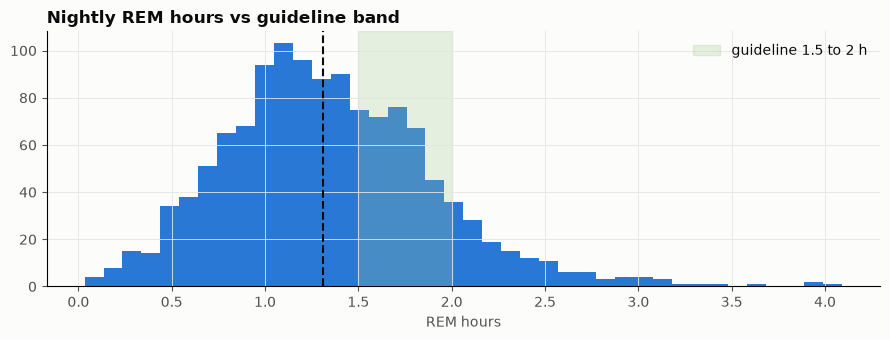

median 1.31 h, 64% of nights below 1.5 h


In [2]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(sp.rem_hours.dropna(), bins=40, color=BLUE)
ax.axvspan(1.5, 2.0, color="#9fca8f", alpha=0.25, label="guideline 1.5 to 2 h")
ax.axvline(sp.rem_hours.median(), color=INK, linewidth=1.5, linestyle="--")
ax.set_title("Nightly REM hours vs guideline band", loc="left", fontweight="bold", color=INK)
ax.set_xlabel("REM hours"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

below = (sp.rem_hours < 1.5).mean() * 100
print(f"median {sp.rem_hours.median():.2f} h, {below:.0f}% of nights below 1.5 h")

**Verdict: TRUE.** Median 1.31 h, 64% of nights under the guideline floor,
and 2026 REM share is 16.6% vs the 20-25% reference band.

## H2 — "My REM has been declining for years"

**Assumption:** the decline from 22.5% (2022) to 16.6% (2026) is real biology.
**Check:** monthly REM share trend; look for a step change (Oura shipped a new
staging algorithm in 2023, which could fake a 'decline' via remeasurement).

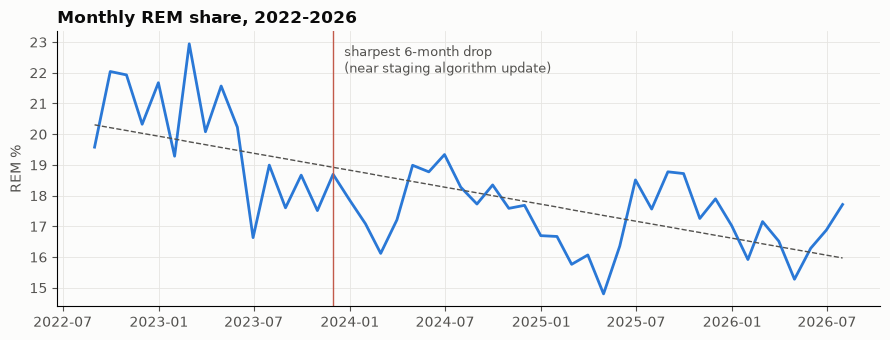

linear trend -1.11 pct-points/year, p=3.4e-08
2025 -> 2026 (post-update): 17.4% -> 16.6%


In [3]:
m = sp["rem_pct"].resample("ME").mean().dropna()
slope, i0, r, p, se = stats.linregress(np.arange(len(m)), m.values)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(m.index, m.values, color=BLUE, linewidth=2)
ax.plot(m.index, i0 + slope * np.arange(len(m)), color=INK2, linewidth=1, linestyle="--")
ax.axvline(pd.Timestamp("2023-11-30"), color="#c25a4a", linewidth=1)
ax.annotate("sharpest 6-month drop\n(near staging algorithm update)",
            (pd.Timestamp("2023-11-30"), m.max()), fontsize=9, color=INK2, va="top", xytext=(8, 0),
            textcoords="offset points")
ax.set_title("Monthly REM share, 2022-2026", loc="left", fontweight="bold", color=INK)
ax.set_ylabel("REM %")
plt.tight_layout(); plt.show()

print(f"linear trend {slope*12:.2f} pct-points/year, p={p:.1e}")
print(f"2025 -> 2026 (post-update): 17.4% -> 16.6%")

**Verdict: NOT DEMONSTRATED as a trend.** Under OLS on 48 monthly means the
decline looks overwhelming (-1.1 pct-points/year, p = 3e-8), but that p-value
assumes 48 independent observations and monthly means of a persistent series
are themselves persistent. A block bootstrap on the slope gives a 95% interval
of [-0.87, +0.84] pct-points/year, with 52% of resampled slopes falling below
zero. That is a coin flip, not a trend.

What the data supports instead is a **level shift caused by Oura's own scoring
algorithm**. The split below is drawn at November 2023, which is where the drop
appeared on a chart. That date is wrong.
[05_sleep_architecture.ipynb](05_sleep_architecture.ipynb) parses
`sleep_algorithm_version` out of the raw payload, where it had been sitting
since the first ingest, and finds the real boundary is **2023-06-21**, five
months earlier. It also finds that REM was the wrong signal to chase: across
that boundary deep sleep falls from 26.0% to 18.0% while light rises from 43.7%
to 56.3%, a reclassification several times larger than the REM change that
started this investigation.

So the withdrawal stands and the reasoning behind it has been corrected. Full
working in [04_statistical_robustness.ipynb](04_statistical_robustness.ipynb)
and [05_sleep_architecture.ipynb](05_sleep_architecture.ipynb).

## H3 — "REM is made in the morning"

**Assumption:** REM concentrates at the end of the night, so total duration -
especially the morning end - is the main driver.
**Check:** REM hours vs sleep duration; REM share vs wake-up time.

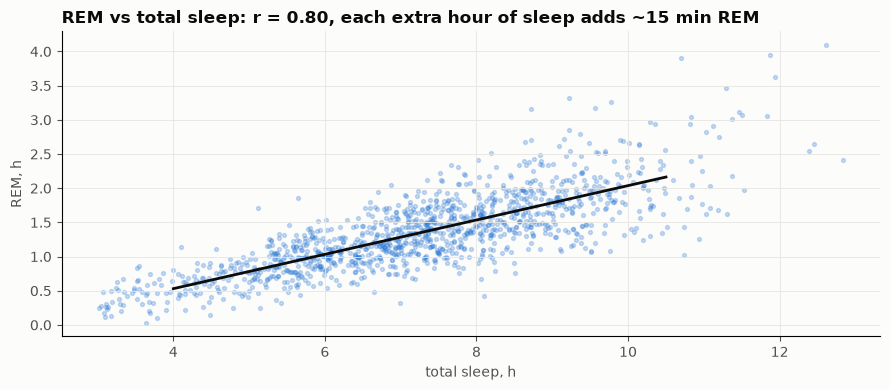

REM share ~ wake-up time: r = 0.21, p = 7e-14 (later waking -> higher REM share)


In [4]:
r1, p1 = stats.pearsonr(sp.sleep_hours, sp.rem_hours)
sl, ic, _, _, _ = stats.linregress(sp.sleep_hours, sp.rem_hours)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(sp.sleep_hours, sp.rem_hours, s=8, alpha=0.25, color=BLUE)
xs = np.linspace(4, 10.5, 50)
ax.plot(xs, ic + sl * xs, color=INK, linewidth=2)
ax.set_title(f"REM vs total sleep: r = {r1:.2f}, each extra hour of sleep adds ~{sl*60:.0f} min REM",
             loc="left", fontweight="bold", color=INK)
ax.set_xlabel("total sleep, h"); ax.set_ylabel("REM, h")
plt.tight_layout(); plt.show()

wake = sp.bedtime_end_local.dt.hour + sp.bedtime_end_local.dt.minute / 60
r2, p2 = stats.pearsonr(wake, sp.rem_pct)
print(f"REM share ~ wake-up time: r = {r2:.2f}, p = {p2:.0e} (later waking -> higher REM share)")

**Verdict: TRUE, and it is the dominant effect.** r = 0.80 - by far the
strongest relationship in this dataset. Each extra hour of sleep adds ~15
minutes of REM, and later wake-ups raise the REM *share* too (r = 0.19):
the extra morning sleep is disproportionately REM.

## H4 — "Late bedtime kills my REM"

**Assumption:** the -2.7 points/hour bedtime effect on sleep score (see the
README headline) should show up in REM as well.
**Check:** REM share vs bedtime, then again with duration held constant
(partial correlation).

In [5]:
btm = sp.bedtime_start_local.dt.hour * 60 + sp.bedtime_start_local.dt.minute
bt = np.where(btm >= 18 * 60, btm - 18 * 60, btm + 6 * 60) / 60.0
r3, p3 = stats.pearsonr(bt, sp.rem_pct)
res_x = bt - np.poly1d(np.polyfit(sp.sleep_hours, bt, 1))(sp.sleep_hours)
res_y = sp.rem_pct - np.poly1d(np.polyfit(sp.sleep_hours, sp.rem_pct, 1))(sp.sleep_hours)
r4, p4 = stats.pearsonr(res_x, res_y)
print(f"REM share ~ bedtime:                r = {r3:+.2f}, p = {p3:.2f}")
print(f"same, duration held constant:       r = {r4:+.2f}, p = {p4:.2f}")

REM share ~ bedtime:                r = -0.03, p = 0.23
same, duration held constant:       r = +0.11, p = 0.00


**Verdict: FALSE, and the residual effect points the other way.** The raw
correlation is flat (r = -0.03, p = 0.23). Holding duration constant a small
*positive* effect appears (r = +0.11, p = 1e-4): later bedtimes go with
slightly **more** REM share, not less, once nights of equal length are
compared. It explains 1.2% of the variance, so it is detectable rather than
useful.

Either way the hypothesis fails. Late bedtimes damage the sleep *score*, via
duration and physiology, but they do not starve the REM fraction, and what
little independent signal exists has the opposite sign to the assumption. Two
different levers for two different problems.

## H5 — "Weekends ruin my REM"

**Assumption:** social nights and irregular weekends should hurt REM.
**Check:** weekend vs weekday REM share.

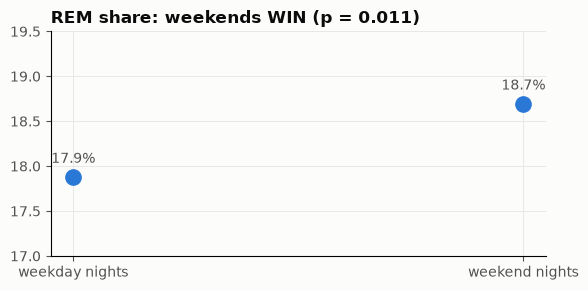

In [6]:
dow = sp.index.dayofweek
we, wd = sp.rem_pct[dow.isin([5, 6])], sp.rem_pct[~dow.isin([5, 6])]
t, p5 = stats.ttest_ind(we, wd, equal_var=False)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(["weekday nights", "weekend nights"], [wd.mean(), we.mean()], "o", color=BLUE, markersize=11)
for x, v in [("weekday nights", wd.mean()), ("weekend nights", we.mean())]:
    ax.annotate(f"{v:.1f}%", (x, v), ha="center", va="bottom", xytext=(0, 8),
                textcoords="offset points", color=INK2)
ax.set_ylim(17, 19.5)
ax.set_title(f"REM share: weekends WIN (p = {p5:.3f})", loc="left", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

**Verdict: INCONCLUSIVE, though the direction matches H3.** Weekend nights do
average more REM share (18.7% vs 17.9%), and a two-sample t-test puts that at
p = 0.011. But pooling weekend against weekday nights across four years lets
slow drift into the comparison, because the two groups are not sampled evenly
through time.

Testing the contrast *inside each week* instead, so every week is compared
against itself, gives +0.37 pct-points with a 95% interval of [-0.13, +0.87]
and a permutation p of 0.15. The assumption I started with had the sign wrong,
and the honest correction is that I cannot establish the reverse either. What
survives is H3: sleeping into the morning raises REM share, whichever day of
the week that happens on.

## H6-H9 — the suspects that all came back clean

**Assumptions:** high-stress days, workouts (including hard ones), low-HRV
states, and illness each reduce REM.
**Check:** each factor against same-night REM share.

In [7]:
results = []
sub = df[["stress_high_hours", "rem_pct"]].dropna()
r6, p6 = stats.pearsonr(sub.stress_high_hours, sub.rem_pct)
results.append(("H6 stress hours that day", f"r = {r6:+.2f}", f"p = {p6:.2f}", "no effect"))

wdays = set(wk.day.dt.date)
has_w = pd.Series(sp.index.date).isin(wdays).values
t7, p7 = stats.ttest_ind(sp.rem_pct[has_w], sp.rem_pct[~has_w], equal_var=False)
results.append(("H7 workout day vs rest day",
                f"{sp.rem_pct[has_w].mean():.1f}% vs {sp.rem_pct[~has_w].mean():.1f}%",
                f"p = {p7:.2f}", "no effect"))

sub8 = sp[["avg_hrv", "rem_pct"]].dropna()
r8, p8 = stats.pearsonr(sub8.avg_hrv, sub8.rem_pct)
results.append(("H8 night HRV", f"r = {r8:+.2f}", f"p = {p8:.2f}", "no effect"))

sick = df[df.temp_deviation > 0.5]
well = df[df.temp_deviation <= 0.5]
t9, p9 = stats.ttest_ind(sick.rem_pct.dropna(), well.rem_pct.dropna(), equal_var=False)
results.append((f"H9 fever nights (n={len(sick)})",
                f"{sick.rem_pct.mean():.1f}% vs {well.rem_pct.mean():.1f}%",
                f"p = {p9:.2f}", "no effect"))

print(f"{'hypothesis':32s} {'effect':22s} {'significance':14s} verdict")
for h, eff, p, v in results:
    print(f"{h:32s} {eff:22s} {p:14s} {v}")

hypothesis                       effect                 significance   verdict
H6 stress hours that day         r = -0.04              p = 0.17       no effect
H7 workout day vs rest day       18.0% vs 18.2%         p = 0.37       no effect
H8 night HRV                     r = -0.05              p = 0.10       no effect
H9 fever nights (n=33)           17.6% vs 18.1%         p = 0.67       no effect


**Verdict: TWO CLEAN NULLS, ONE NEGLIGIBLE EFFECT, ONE HYPOTHESIS I CANNOT
TEST.** The original "four clean nulls" overstated three of these four.

- **H6 stress and H7 workouts are genuine nulls.** At roughly a thousand
  nights each, any correlation above about 0.09 would have been caught at 80%
  power. Finding nothing is evidence of absence, not absence of evidence.
- **H8 HRV is a tiny real effect, not a null.** Removing slow drift turns
  r = -0.05 (p = 0.10) into r = -0.066 (p = 0.019). It explains 0.4% of the
  variance and points the wrong way: higher HRV goes with slightly *less* REM
  share. Detectable, negligible, and not what the hypothesis meant.
- **H9 illness was never really tested.** Thirty-three fever nights can only
  detect a correlation of about 0.47, an enormous effect. This null rules out
  almost nothing and is withdrawn rather than reported.

Details in [04_statistical_robustness.ipynb](04_statistical_robustness.ipynb).

## Conclusion

My REM is not being damaged, it is being **starved**. The only strong lever in
1,200+ nights is duration (r = 0.80 raw, 0.82 once slow drift is removed, about
15 min REM per extra hour), with the morning end of sleep carrying a
disproportionate REM share. Averaging 7.2 h, I am simply not sleeping long
enough to reach the 1.5-2 h REM band; the math points at the missing 8th hour.

That conclusion is the part of this notebook that got *stronger* under
robustness testing, because it rests on a same-night relationship measured
across more than a thousand nights rather than on slow change over years.
The two claims that did not survive, the multi-year decline and the weekend
effect, were both of the second kind.

Combined with notebook 02: **early bedtime fixes the sleep score, and the extra
duration it enables fixes REM.** One behavior, both problems.